# Modelo Baseline: DenseNet-121 (Ponto Zero)

Este notebook define o desempenho inicial de referência utilizando a estrutura padronizada do projeto, mas mantendo as **configurações mínimas**:
- **Arquitetura:** DenseNet-121 (Backbone 100% congelado).
- **Data Augmentation:** Leve (Resize + Horizontal Flip).
- **Otimizador:** Adam (LR constante, sem scheduler).
- **Métricas:** Curvas de aprendizado e Matriz de Confusão inclusas.

In [11]:
# =========================================================
# Setup: Bibliotecas e Reprodutibilidade
# =========================================================
import os, random, warnings, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import confusion_matrix, f1_score, classification_report

import torch, torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = torch.cuda.is_available()
print(f"Device: {device} | AMP: {use_amp}")

# Diretório para salvar os modelos
SAVE_DIR = Path("../models")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

Device: cuda | AMP: True


In [12]:
# ============================
# Configuração do Dataset
# ============================
DATA_ROOT = Path('/home/gustavom/Documents/Orange/Brain Tumor MRI Dataset')
TRAIN_DIR = DATA_ROOT / "Training"
TEST_DIR  = DATA_ROOT / "Testing"

assert TRAIN_DIR.exists(), f"Pasta {TRAIN_DIR} não encontrada."
assert TEST_DIR.exists(), f"Pasta {TEST_DIR} não encontrada."

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Augmentation LEVE para o Baseline
train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

val_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# Uso das pastas completas conforme solicitado
train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_tfms)
val_ds   = datasets.ImageFolder(TEST_DIR,  transform=val_tfms)

class_names = train_ds.classes
print("Classes encontradas:", class_names)
print(f"Qtd Treino: {len(train_ds)} | Qtd Teste/Val: {len(val_ds)}")

batch_size = 32
num_workers = 2 if torch.cuda.is_available() else 0
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=num_workers, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

Classes encontradas: ['glioma', 'meningioma', 'notumor', 'pituitary']
Qtd Treino: 5600 | Qtd Teste/Val: 1600


In [13]:
# ============================
# Modelo: DenseNet-121 Baseline
# ============================
weights = models.DenseNet121_Weights.IMAGENET1K_V1
model = models.densenet121(weights=weights)

# Baseline: Congela TODO o backbone
for p in model.features.parameters():
    p.requires_grad = False

# Cabeça treinável
num_classes = len(class_names)
in_feats = model.classifier.in_features
model.classifier = nn.Linear(in_feats, num_classes)

model = model.to(device)

In [14]:
# ============================
# Otimizador e Early Stopping
# ============================
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

class EarlyStopping:
    def __init__(self, patience=5, min_delta=1e-4, path="baseline_densenet121.pth"):
        self.patience = patience
        self.min_delta = min_delta
        self.path = path
        self.best = float("inf")
        self.counter = 0
        self.best_state = None

    def step(self, val_loss, model):
        if val_loss < self.best - self.min_delta:
            self.best = val_loss
            self.counter = 0
            # Salva o estado no CPU para evitar problemas de compatibilidade/memória
            self.best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}
            torch.save(self.best_state, self.path)
            return False
        else:
            self.counter += 1
            return self.counter > self.patience

early_stopper = EarlyStopping(patience=5, min_delta=1e-4, path=SAVE_DIR / "variacao0_densenet121.pth")

In [15]:
# ============================
# Funções de Treino e Plot
# ============================
def run_epoch(model, loader, train=True):
    model.train(mode=train)
    total_loss, total_correct, total = 0.0, 0, 0
    all_preds, all_targets = [], []

    for X, y in loader:
        X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)

        if train:
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=use_amp):
                logits = model(X)
                loss = criterion(logits, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            with torch.no_grad():
                logits = model(X)
                loss = criterion(logits, y)

        preds = logits.argmax(1)
        total_loss += loss.item() * y.size(0)
        total_correct += (preds == y).sum().item()
        total += y.size(0)
        all_preds.append(preds.detach().cpu().numpy())
        all_targets.append(y.detach().cpu().numpy())

    avg_loss = total_loss / total
    acc = total_correct / total
    y_true = np.concatenate(all_targets)
    y_pred = np.concatenate(all_preds)
    f1 = f1_score(y_true, y_pred, average='macro')
    return avg_loss, acc, f1, y_true, y_pred

def plot_curve(hist, k1, k2, title, ylab):
    plt.figure(figsize=(6,4))
    plt.plot(hist[k1], label=k1)
    plt.plot(hist[k2], label=k2)
    plt.xlabel("epoch"); plt.ylabel(ylab); plt.title(title); plt.legend(); plt.show()

def plot_cm(cm, classes, normalize=False, title="Confusion Matrix"):
    if normalize: cm = cm.astype(float)/cm.sum(axis=1, keepdims=True)
    import itertools
    plt.figure(figsize=(6,4))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues); plt.title(title); plt.colorbar()
    ticks = np.arange(len(classes)); plt.xticks(ticks, classes, rotation=45); plt.yticks(ticks, classes)
    fmt = ".2f" if normalize else "d"; thresh = cm.max()/2
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i,j], fmt), ha="center",
                 color="white" if cm[i,j] > thresh else "black")
    plt.ylabel("True"); plt.xlabel("Pred"); plt.tight_layout(); plt.show()

In [16]:
# ============================
# Treinamento
# ============================
EPOCHS = 50
history = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[], "val_f1":[]}

print("Iniciando treinamento...")
for e in range(1, EPOCHS+1):
    tr_loss, tr_acc, _, _, _ = run_epoch(model, train_loader, train=True)
    va_loss, va_acc, va_f1, y_true, y_pred = run_epoch(model, val_loader, train=False)

    history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc);   history["val_acc"].append(va_acc); history["val_f1"].append(va_f1)

    print(f"[{e}/{EPOCHS}] train_loss={tr_loss:.4f} acc={tr_acc:.4f} | val_loss={va_loss:.4f} acc={va_acc:.4f} f1={va_f1:.4f}")

    if early_stopper.step(va_loss, model):
        print(f"Early stopping ativado na época {e}.")
        break

Iniciando treinamento...
[1/50] train_loss=0.6412 acc=0.7891 | val_loss=0.5555 acc=0.8006 f1=0.7923
[2/50] train_loss=0.3799 acc=0.8707 | val_loss=0.4921 acc=0.8306 f1=0.8253
[3/50] train_loss=0.3186 acc=0.8909 | val_loss=0.4712 acc=0.8419 f1=0.8374
[4/50] train_loss=0.3049 acc=0.8934 | val_loss=0.4965 acc=0.8313 f1=0.8254
[5/50] train_loss=0.2805 acc=0.9016 | val_loss=0.4513 acc=0.8538 f1=0.8527
[6/50] train_loss=0.2686 acc=0.9034 | val_loss=0.4400 acc=0.8588 f1=0.8585
[7/50] train_loss=0.2491 acc=0.9132 | val_loss=0.4683 acc=0.8525 f1=0.8482
[8/50] train_loss=0.2455 acc=0.9123 | val_loss=0.4504 acc=0.8575 f1=0.8544
[9/50] train_loss=0.2312 acc=0.9198 | val_loss=0.4342 acc=0.8644 f1=0.8612
[10/50] train_loss=0.2417 acc=0.9082 | val_loss=0.4505 acc=0.8638 f1=0.8605
[11/50] train_loss=0.2242 acc=0.9198 | val_loss=0.3940 acc=0.8775 f1=0.8751
[12/50] train_loss=0.2155 acc=0.9252 | val_loss=0.4688 acc=0.8700 f1=0.8673
[13/50] train_loss=0.2183 acc=0.9196 | val_loss=0.4839 acc=0.8675 f1=0.8

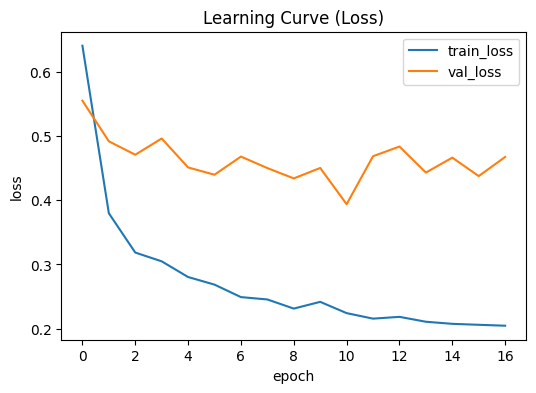

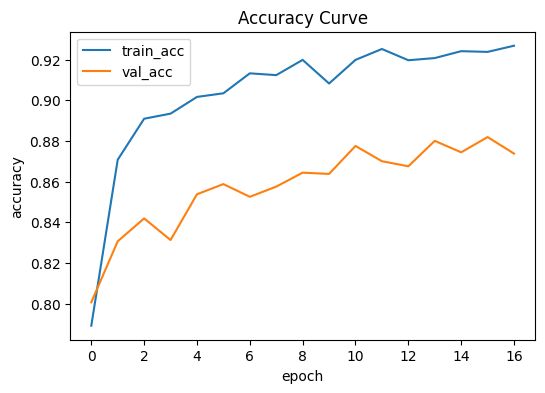

Melhor modelo carregado de ../models/baseline_densenet121.pth

Melhor F1-Score (Macro): 0.8527

Classification Report:
               precision    recall  f1-score   support

      glioma       0.95      0.68      0.79       400
  meningioma       0.71      0.86      0.78       400
     notumor       0.88      0.98      0.93       400
   pituitary       0.93      0.90      0.92       400

    accuracy                           0.85      1600
   macro avg       0.87      0.85      0.85      1600
weighted avg       0.87      0.85      0.85      1600



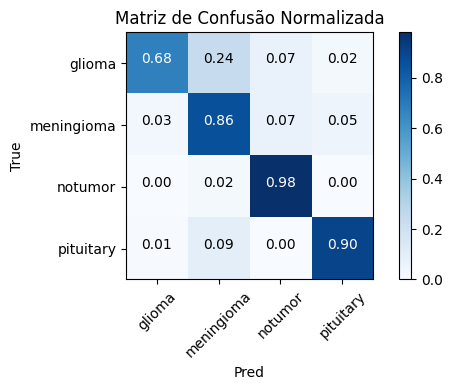

In [17]:
# ============================
# Resultados Finais
# ============================
plot_curve(history, "train_loss", "val_loss", "Learning Curve (Loss)", "loss")
plot_curve(history, "train_acc",  "val_acc",  "Accuracy Curve", "accuracy")

# Carrega o melhor e avalia uma última vez
best_path = SAVE_DIR / "baseline_densenet121.pth"
if os.path.exists(best_path):
    state = torch.load(best_path, map_location=device)
    model.load_state_dict(state)
    print(f"Melhor modelo carregado de {best_path}")

_, _, val_f1, y_true, y_pred = run_epoch(model, val_loader, train=False)

print(f"\nMelhor F1-Score (Macro): {val_f1:.4f}")
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plot_cm(cm, class_names, normalize=True, title="Matriz de Confusão Normalizada")